In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [165]:
df = pd.read_csv("D:\GitHub Project\A_DATA ANALYST SIMULATION\DAY 2\customerorder.csv")
df

,CUST_ID,ORDER_ID,ORDER_DATETIME,DAYS_ELAPSED_TMAX,DAYS_FROM_CUST_LAST_ORDER,REVENUE,QUANTITY,STORE_ID,PRODUCT_ID,ORDER_STATUS,SHIPMENT_STATUS
0,1,159,2021-04-20 12:51:57,357,271,39.16,2,1,8,COMPLETE,DELIVERED
1,1,182,2021-04-26 03:56:02,351,265,41.32,4,1,23,COMPLETE,DELIVERED
2,1,182,2021-04-26 03:56:02,351,265,56.42,2,1,20,COMPLETE,DELIVERED
3,1,201,2021-04-29 11:48:01,348,262,98.24,2,1,36,COMPLETE,DELIVERED
4,1,201,2021-04-29 11:48:01,348,262,57.36,4,1,19,COMPLETE,DELIVERED
...,...,...,...,...,...,...,...,...,...,...,...
995,106,10,2021-02-23 14:02:10,413,392,119.73,3,1,27,COMPLETE,DELIVERED
996,106,10,2021-02-23 14:02:10,413,392,131.13,3,1,5,COMPLETE,DELIVERED
997,106,123,2021-04-10 08:05:01,367,346,14.34,1,1,19,COMPLETE,DELIVERED
998,106,123,2021-04-10 08:05:01,367,346,22.00,2,1,39,COMPLETE,DELIVERED


In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CUST_ID                    1000 non-null   int64  
 1   ORDER_ID                   1000 non-null   int64  
 2   ORDER_DATETIME             1000 non-null   object 
 3   DAYS_ELAPSED_TMAX          1000 non-null   int64  
 4   DAYS_FROM_CUST_LAST_ORDER  1000 non-null   int64  
 5   REVENUE                    1000 non-null   float64
 6   QUANTITY                   1000 non-null   int64  
 7   STORE_ID                   1000 non-null   int64  
 8   PRODUCT_ID                 1000 non-null   int64  
 9   ORDER_STATUS               1000 non-null   object 
 10  SHIPMENT_STATUS            685 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 86.1+ KB


In [167]:
df.isnull().sum()

CUST_ID                        0
ORDER_ID                       0
ORDER_DATETIME                 0
DAYS_ELAPSED_TMAX              0
DAYS_FROM_CUST_LAST_ORDER      0
REVENUE                        0
QUANTITY                       0
STORE_ID                       0
PRODUCT_ID                     0
ORDER_STATUS                   0
SHIPMENT_STATUS              315
dtype: int64

In [168]:
df['ORD_DATETIME'] = pd.to_datetime(df['ORDER_DATETIME'])

In [169]:
# handling null values with new variable Pending or no record
df['SHIPMENT_STATUS'] = df['SHIPMENT_STATUS'].fillna('PENDING/NORECORD')

In [170]:
df['SHIPMENT_STATUS'].value_counts()

SHIPMENT_STATUS
DELIVERED           685
PENDING/NORECORD    315
Name: count, dtype: int64

In [171]:
# Define the aggregation for core features
agg_dict = {
    # Recency (R) & Tenure
    # R is the MINIMUM DAYS_ELAPSED_TMAX (since the smallest gap means the latest order)
    'DAYS_ELAPSED_TMAX': ['min', 'max'], 
    
    # Monetary (M)
    'REVENUE': 'sum',
    
    # Frequency (F) - Count of unique order IDs
    'ORDER_ID': 'nunique',
    
    # 4. Item/Product Variety
    'PRODUCT_ID': 'nunique',
    'STORE_ID': 'nunique',
    
    # 5. IPI (Inter-Purchase Interval) - Only consider non-zero time differences
    'DAYS_FROM_CUST_LAST_ORDER': lambda x: np.mean(x[x > 0]),
    'QUANTITY': ['sum', 'mean']
}

customer_df = df.groupby('CUST_ID').agg(agg_dict).reset_index()

In [172]:
customer_df

CUST_ID DAYS_ELAPSED_TMAX       REVENUE ORDER_ID PRODUCT_ID STORE_ID  \
                          min  max      sum  nunique    nunique  nunique   
0         1                86  357   397.22        5          8        1   
1         2               215  425   332.99        2          4        2   
2         3                82  432  1765.44       10         19        2   
3         4                89  284  1263.27        7         12        2   
4         5               224  320   150.74        3          3        2   
..      ...               ...  ...      ...      ...        ...      ...   
101     102                76  325   830.47        7         10        2   
102     103                62  221   392.52        4          6        2   
103     104                57  329  1051.78        6         12        2   
104     105                60  343   815.38        6         10        2   
105     106               367  413   454.35        2          6        1   

    DAYS_FROM_CUST_LAST_ORDER QUANTITY            
                     <lambda>      sum      mean  
0                  171.625000       22  2.444444  
1                  210.000000       17  4.250000  
2                  231.550000       76  3.304348  
3                  130.833333       44  3.142857  
4                   92.500000        8  2.666667  
..                        ...      ...       ...  
101                100.222222       34  3.090909  
102                122.400000       20  2.857143  
103                119.545455       41  3.153846  
104                200.272727       32  2.461538  
105                369.000000       19  3.166667  

[106 rows x 10 columns]

In [173]:
# Flatten the multi-level column names
customer_df.columns = [
    'CUST_ID', 
    'RECENCY_DAYS', 'TENURE_DAYS', 
    'MONETARY', 'FREQUENCY_ORDERS', 
    'PRODUCT_VARIETY', 'STORE_VARIETY',
    'IPI_AVG_DAYS', 
    'TOTAL_QUANTITY', 'AVG_QUANTITY_PER_ITEM'
]

In [174]:
customer_df.head()

,CUST_ID,RECENCY_DAYS,TENURE_DAYS,MONETARY,FREQUENCY_ORDERS,PRODUCT_VARIETY,STORE_VARIETY,IPI_AVG_DAYS,TOTAL_QUANTITY,AVG_QUANTITY_PER_ITEM
0,1,86,357,397.22,5,8,1,171.625000,22,2.444444
1,2,215,425,332.99,2,4,2,210.000000,17,4.250000
2,3,82,432,1765.44,10,19,2,231.550000,76,3.304348
3,4,89,284,1263.27,7,12,2,130.833333,44,3.142857
4,5,224,320,150.74,3,3,2,92.500000,8,2.666667


In [175]:
# Derived and Proportion Features
# Average Order Value (AOV)
customer_df['AOV'] = customer_df['MONETARY'] / customer_df['FREQUENCY_ORDERS']

# Target Variable (CHURNED)
# Apply rule: Churn if Recency (days since last purchase) > 90
customer_df['CHURN'] = (customer_df['RECENCY_DAYS'] > 90).astype(int)

# Service Status Proportions (Requires re-aggregation)
status_df = df.groupby('CUST_ID')['SHIPMENT_STATUS'].value_counts(normalize=True).unstack(fill_value=0)
status_df.columns = ['SHIP_' + col for col in status_df.columns]

In [176]:
customer_df.head()

,CUST_ID,RECENCY_DAYS,TENURE_DAYS,MONETARY,FREQUENCY_ORDERS,PRODUCT_VARIETY,STORE_VARIETY,IPI_AVG_DAYS,TOTAL_QUANTITY,AVG_QUANTITY_PER_ITEM,AOV,CHURN
0,1,86,357,397.22,5,8,1,171.625000,22,2.444444,79.444000,0
1,2,215,425,332.99,2,4,2,210.000000,17,4.250000,166.495000,1
2,3,82,432,1765.44,10,19,2,231.550000,76,3.304348,176.544000,0
3,4,89,284,1263.27,7,12,2,130.833333,44,3.142857,180.467143,0
4,5,224,320,150.74,3,3,2,92.500000,8,2.666667,50.246667,1


In [177]:
status_df.head()

,SHIP_DELIVERED,SHIP_PENDING/NORECORD
CUST_ID,,
1,1.000000,0.000000
2,0.500000,0.500000
3,0.695652,0.304348
4,0.642857,0.357143
5,0.666667,0.333333


In [178]:
final_df1 = customer_df.merge(status_df, on='CUST_ID', how='left')

In [179]:
final_df1

,CUST_ID,RECENCY_DAYS,TENURE_DAYS,MONETARY,FREQUENCY_ORDERS,PRODUCT_VARIETY,STORE_VARIETY,IPI_AVG_DAYS,TOTAL_QUANTITY,AVG_QUANTITY_PER_ITEM,AOV,CHURN,SHIP_DELIVERED,SHIP_PENDING/NORECORD
0,1,86,357,397.22,5,8,1,171.625000,22,2.444444,79.444000,0,1.000000,0.000000
1,2,215,425,332.99,2,4,2,210.000000,17,4.250000,166.495000,1,0.500000,0.500000
2,3,82,432,1765.44,10,19,2,231.550000,76,3.304348,176.544000,0,0.695652,0.304348
3,4,89,284,1263.27,7,12,2,130.833333,44,3.142857,180.467143,0,0.642857,0.357143
4,5,224,320,150.74,3,3,2,92.500000,8,2.666667,50.246667,1,0.666667,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,102,76,325,830.47,7,10,2,100.222222,34,3.090909,118.638571,0,0.545455,0.454545
102,103,62,221,392.52,4,6,2,122.400000,20,2.857143,98.130000,0,0.571429,0.428571
103,104,57,329,1051.78,6,12,2,119.545455,41,3.153846,175.296667,0,0.846154,0.153846
104,105,60,343,815.38,6,10,2,200.272727,32,2.461538,135.896667,0,0.846154,0.153846


Exploratory Data Analysis (EDA)

In [180]:
final_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CUST_ID                106 non-null    int64  
 1   RECENCY_DAYS           106 non-null    int64  
 2   TENURE_DAYS            106 non-null    int64  
 3   MONETARY               106 non-null    float64
 4   FREQUENCY_ORDERS       106 non-null    int64  
 5   PRODUCT_VARIETY        106 non-null    int64  
 6   STORE_VARIETY          106 non-null    int64  
 7   IPI_AVG_DAYS           105 non-null    float64
 8   TOTAL_QUANTITY         106 non-null    int64  
 9   AVG_QUANTITY_PER_ITEM  106 non-null    float64
 10  AOV                    106 non-null    float64
 11  CHURN                  106 non-null    int64  
 12  SHIP_DELIVERED         106 non-null    float64
 13  SHIP_PENDING/NORECORD  106 non-null    float64
dtypes: float64(6), int64(8)
memory usage: 11.7 KB


In [181]:
final_df1.isnull().sum()

CUST_ID                  0
RECENCY_DAYS             0
TENURE_DAYS              0
MONETARY                 0
FREQUENCY_ORDERS         0
PRODUCT_VARIETY          0
STORE_VARIETY            0
IPI_AVG_DAYS             1
TOTAL_QUANTITY           0
AVG_QUANTITY_PER_ITEM    0
AOV                      0
CHURN                    0
SHIP_DELIVERED           0
SHIP_PENDING/NORECORD    0
dtype: int64

In [182]:
final_df1['IPI_AVG_DAYS'] = final_df1['IPI_AVG_DAYS'].fillna(final_df1['IPI_AVG_DAYS'].median())

In [183]:
# Drop uneeded column, tenure days would be highly correlated with recency
final_df = final_df1.drop(columns=['CUST_ID','TENURE_DAYS'])

In [184]:
features = final_df.columns
churn_label = final_df['CHURN'].map({0: 'Active (0)', 1: 'Churned (1)'})

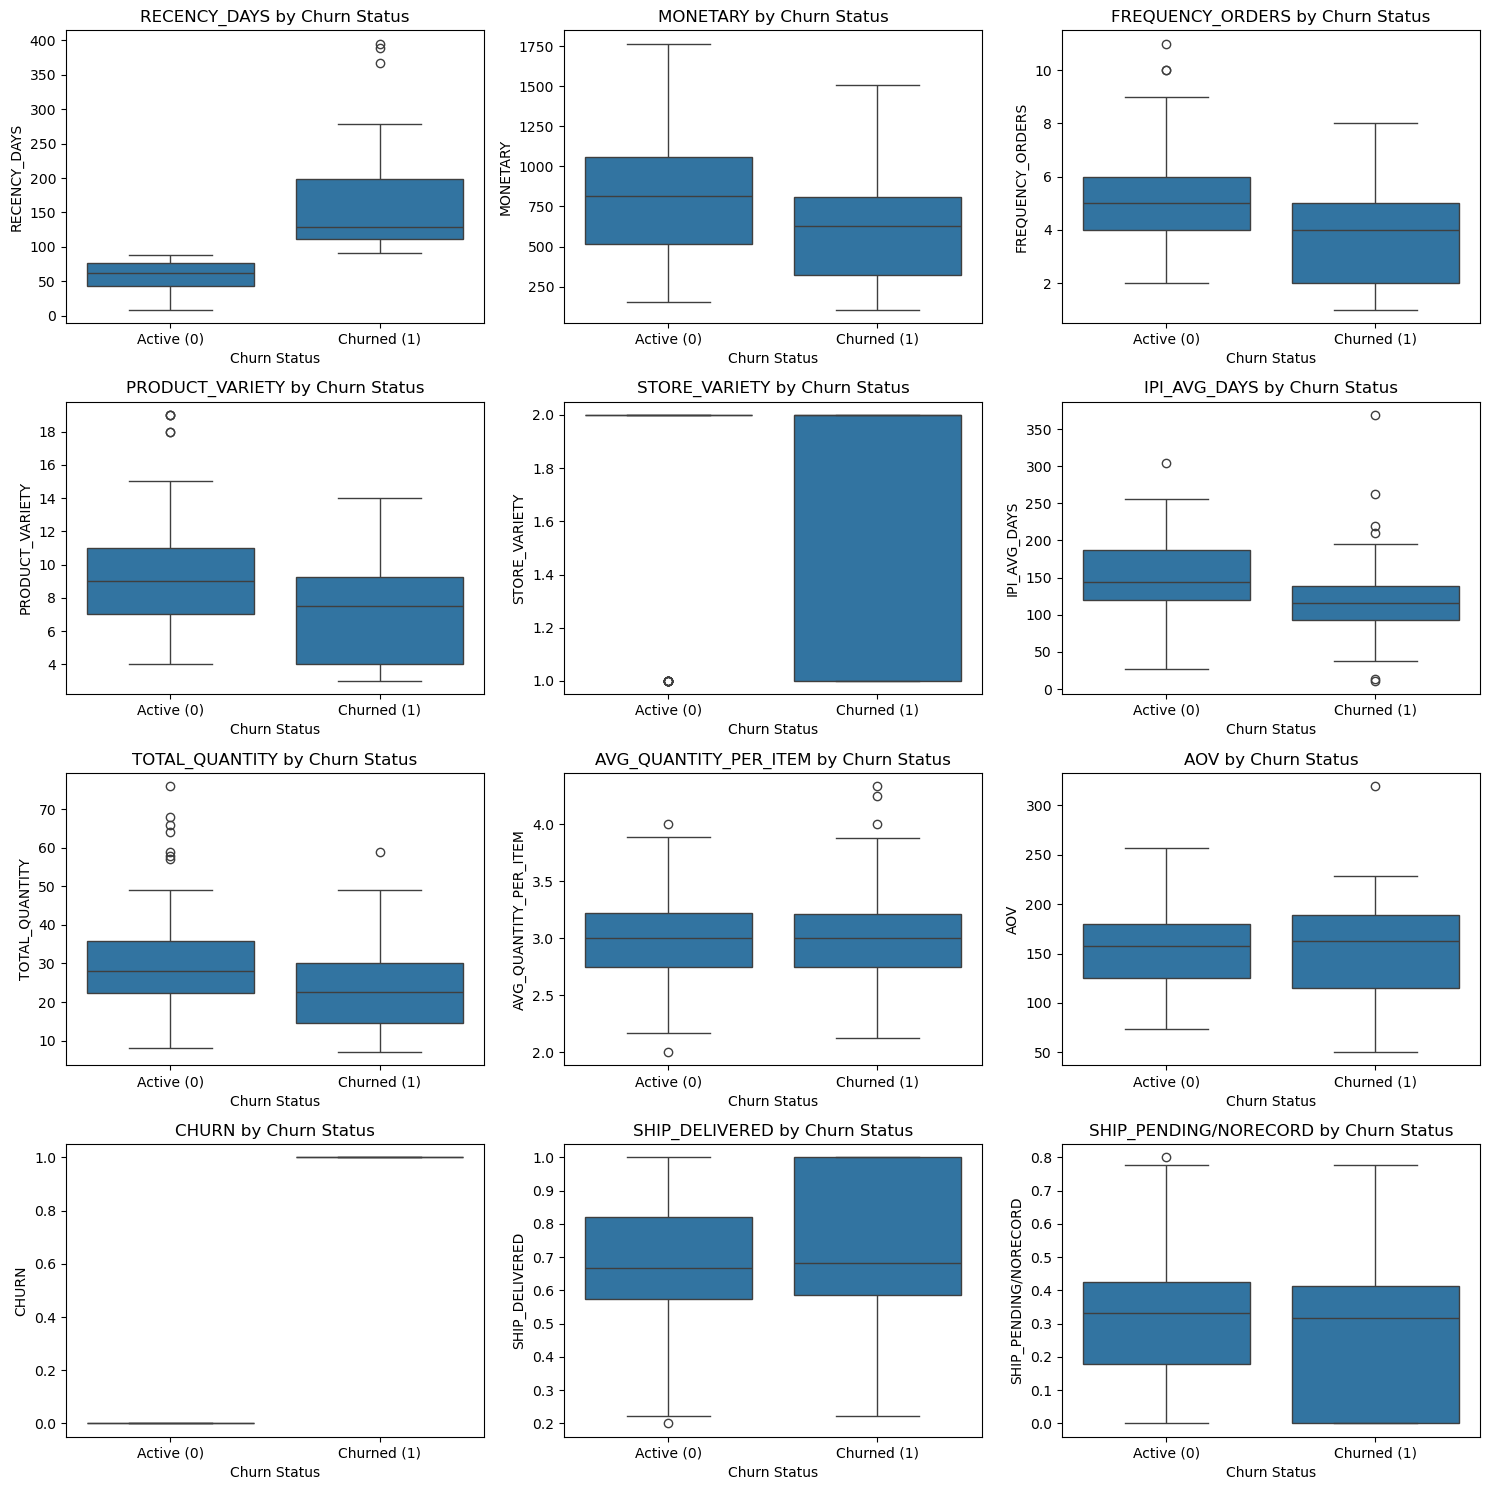

In [185]:
plt.figure(figsize=(15, 15))
for i, feature in enumerate(features):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(x=churn_label, y=feature, data=final_df)
    plt.title(f'{feature} by Churn Status')
    plt.xlabel('Churn Status')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

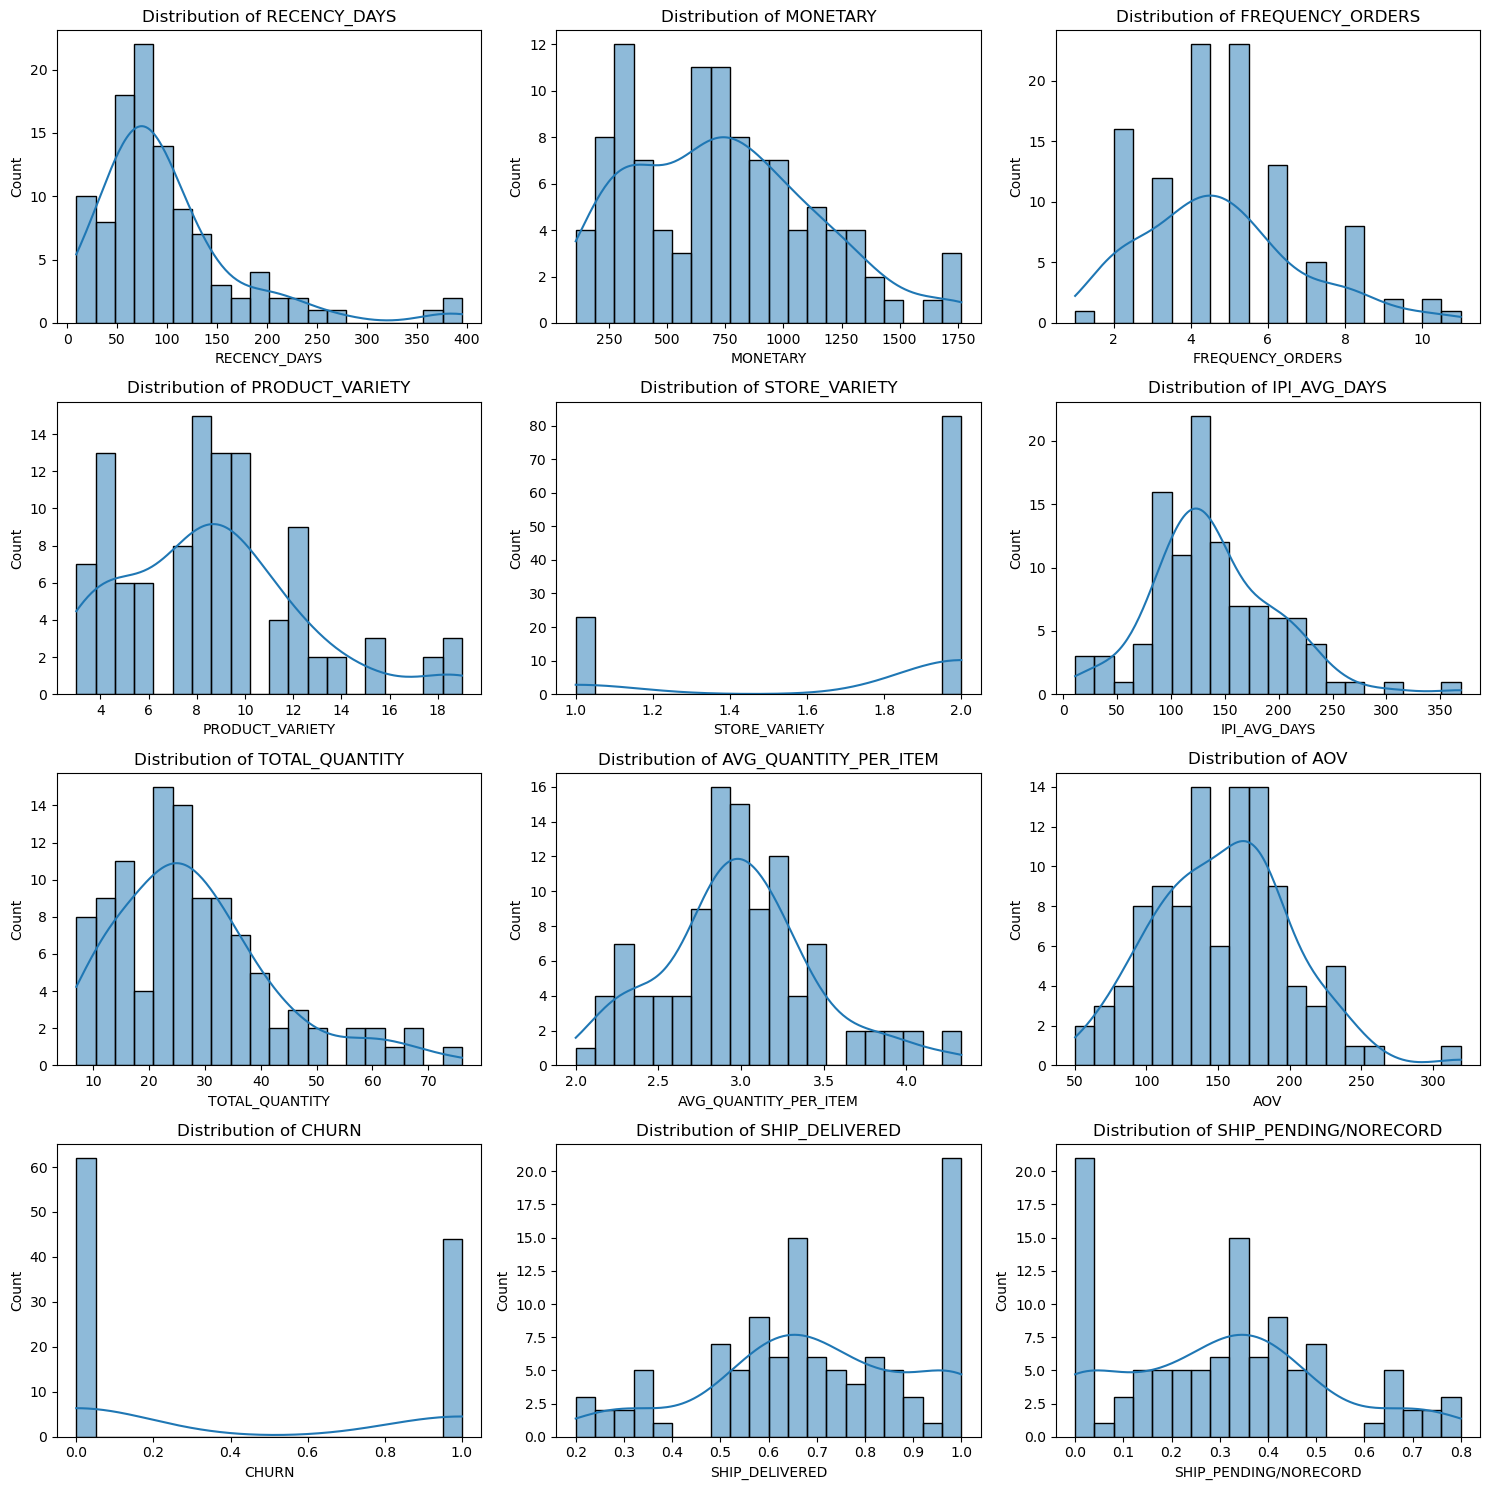

In [186]:
plt.figure(figsize=(15, 15))
for i, feature in enumerate(features):
    plt.subplot(4, 3, i + 1)
    sns.histplot(final_df[feature], bins= 20, kde= True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

Split Data

In [187]:
X = final_df[['MONETARY', 'SHIP_PENDING/NORECORD', 'IPI_AVG_DAYS', 'AVG_QUANTITY_PER_ITEM', 'TOTAL_QUANTITY']]
y = final_df['CHURN']
# the reason why we excluding the recency days because we define the Churn based on Recency value (>90 = Churn)
# our model would get data leakage so its better to exclude Recency_days

In [188]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score, precision_score, f1_score, roc_auc_score, ConfusionMatrixDisplay

In [189]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [190]:
print(f'Training Size: {X_train.shape}')
print(f'Test Size : {X_test.shape}')

Training Size: (84, 5)
Test Size : (22, 5)


In [191]:
X_test.isnull().sum()

MONETARY                 0
SHIP_PENDING/NORECORD    0
IPI_AVG_DAYS             0
AVG_QUANTITY_PER_ITEM    0
TOTAL_QUANTITY           0
dtype: int64

In [192]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

Define Paramater for each Model

In [193]:
lr_parameters = {
    'C': [0.01, 0.1, 1, 10, 100, 1000],
    'penalty': ['l2'], 
    'solver': ['liblinear', 'lbfgs'], 
    'class_weight': ['balanced', None] 
}

dt_parameters = {
    'max_depth': [3, 5, 7, 10, 15, 20, None], 
    'min_samples_split': [2, 5, 10], 
    'min_samples_leaf': [1, 2, 4], 
    'criterion': ['gini', 'entropy'], 
    'class_weight': ['balanced', None]
}

knn_parameters = {
    'n_neighbors': [1, 3, 5, 9, 15, 25],  
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [194]:
lr = LogisticRegression(random_state=42)
lrcv = GridSearchCV(lr, lr_parameters, cv=20, scoring='roc_auc', n_jobs=-1)
lrcv.fit(X_train_scaled, y_train)

GridSearchCV(cv=20, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100, 1000],
                         'class_weight': ['balanced', None], 'penalty': ['l2'],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='roc_auc')

In [195]:
print(f'Best Hyper Parameters : {lrcv.best_params_}')
print(f'Accuracy Score : {lrcv.best_score_}')

Best Hyper Parameters : {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Accuracy Score : 0.6916666666666667


In [196]:
accuracy = lrcv.score(X_test_scaled, y_test)
print(f'Logistic Regression Accuracy score : {accuracy}')

Logistic Regression Accuracy score : 0.8547008547008547


In [197]:
y_pred = lrcv.best_estimator_.predict(X_test_scaled)
y_prob = lrcv.best_estimator_.predict_proba(X_test_scaled)[:, 1]

In [198]:
# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Active (0)', 'Churned (1)']))

# ROC AUC Score
roc_auc = roc_auc_score(y_test, y_prob)
print(f"\nROC AUC Score: {roc_auc:.4f}")


Confusion Matrix:
[[10  3]
 [ 3  6]]

Classification Report:
              precision    recall  f1-score   support

  Active (0)       0.77      0.77      0.77        13
 Churned (1)       0.67      0.67      0.67         9

    accuracy                           0.73        22
   macro avg       0.72      0.72      0.72        22
weighted avg       0.73      0.73      0.73        22


ROC AUC Score: 0.8547


In [199]:
dt = DecisionTreeClassifier(random_state=42)
dtcv = GridSearchCV(dt, dt_parameters, cv=10, scoring='roc_auc', n_jobs=-1)
dtcv.fit(X_train_scaled, y_train)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'class_weight': ['balanced', None],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10, 15, 20, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='roc_auc')

In [200]:
print(f'Best Hyper Parameters : {dtcv.best_params_}')
print(f'Accuracy Score : {dtcv.best_score_}')

Best Hyper Parameters : {'class_weight': None, 'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy Score : 0.5304166666666665


In [201]:
accuracy2 = dtcv.score(X_test_scaled, y_test)
print(f'Decision Tree Accuracy score : {accuracy2}')

Decision Tree Accuracy score : 0.7735042735042734


In [202]:
y_pred2 = dtcv.best_estimator_.predict(X_test_scaled)
y_prob2= dtcv.best_estimator_.predict_proba(X_test_scaled)[:, 1]

In [203]:
# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred2))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred2, target_names=['Active (0)', 'Churned (1)']))

# ROC AUC Score
roc_auc = roc_auc_score(y_test, y_prob2)
print(f"\nROC AUC Score: {roc_auc:.4f}")


Confusion Matrix:
[[10  3]
 [ 2  7]]

Classification Report:
              precision    recall  f1-score   support

  Active (0)       0.83      0.77      0.80        13
 Churned (1)       0.70      0.78      0.74         9

    accuracy                           0.77        22
   macro avg       0.77      0.77      0.77        22
weighted avg       0.78      0.77      0.77        22


ROC AUC Score: 0.7735


In [204]:
knn = KNeighborsClassifier()
knncv = GridSearchCV(knn, knn_parameters, cv=20, scoring='roc_auc', n_jobs=-1)
knncv.fit(X_train_scaled, y_train)

GridSearchCV(cv=20, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [1, 3, 5, 9, 15, 25],
                         'weights': ['uniform', 'distance']},
             scoring='roc_auc')

In [205]:
print(f'Best Hyper Parameters : {knncv.best_params_}')
print(f'Accuracy Score : {knncv.best_score_}')

Best Hyper Parameters : {'metric': 'euclidean', 'n_neighbors': 25, 'weights': 'uniform'}
Accuracy Score : 0.6208333333333333


In [206]:
accuracy3 = knncv.score(X_test_scaled, y_test)
print(f'KNN Accuracy score : {accuracy3}')

KNN Accuracy score : 0.8461538461538461


In [207]:
y_pred3 = knncv.best_estimator_.predict(X_test_scaled)
y_prob3= knncv.best_estimator_.predict_proba(X_test_scaled)[:, 1]

In [208]:
# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred3))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred3, target_names=['Active (0)', 'Churned (1)']))

# ROC AUC Score
roc_auc = roc_auc_score(y_test, y_prob3)
print(f"\nROC AUC Score: {roc_auc:.4f}")


Confusion Matrix:
[[12  1]
 [ 3  6]]

Classification Report:
              precision    recall  f1-score   support

  Active (0)       0.80      0.92      0.86        13
 Churned (1)       0.86      0.67      0.75         9

    accuracy                           0.82        22
   macro avg       0.83      0.79      0.80        22
weighted avg       0.82      0.82      0.81        22


ROC AUC Score: 0.8462


In [209]:
# Define a function to calculate all metrics
def calculate_metrics(model_cv, X_test, y_test, y_pred, y_proba):
    
    # Calculate the additional metrics
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # Calculate ROC_AUC (requires probability estimates)
    try:
        roc_auc = roc_auc_score(y_test, y_proba)
    except ValueError:
        # Handle cases where roc_auc cannot be computed (e.g., only one class present in y_test)
        roc_auc = None 
        
    return [
        model_cv.best_score_, 
        model_cv.score(X_test_scaled, y_test),
        recall,
        precision,
        f1,
        roc_auc
    ]

In [210]:
# Populate the methods dictionary with all metrics
methods = {
    'Logistic Regression': calculate_metrics(lrcv, X_test_scaled, y_test, lr_y_pred, lr_y_proba),
    'Decision Tree': calculate_metrics(dtcv, X_test_scaled, y_test, dt_y_pred, dt_y_proba),
    'KNN Classifier': calculate_metrics(knncv, X_test_scaled, y_test, knn_y_pred, knn_y_proba)
}

# Create the DataFrame and set index labels
model_performance = pd.DataFrame(methods)

indexlabels = [
    'Overall Accuracy (CV)', 
    'Test Set Accuracy', 
    'Test Set Recall', 
    'Test Set Precision', 
    'Test Set F1-Score', 
    'Test Set ROC-AUC'
]

model_performance = model_performance.set_index(pd.Index(indexlabels))
model_performance

,Logistic Regression,Decision Tree,KNN Classifier
Overall Accuracy (CV),0.691667,0.530417,0.620833
Test Set Accuracy,0.854701,0.773504,0.846154
Test Set Recall,0.727273,0.772727,0.818182
Test Set Precision,0.727273,0.778788,0.823377
Test Set F1-Score,0.727273,0.774163,0.813312
Test Set ROC-AUC,0.854701,0.773504,0.846154


<Figure size 1400x600 with 0 Axes>

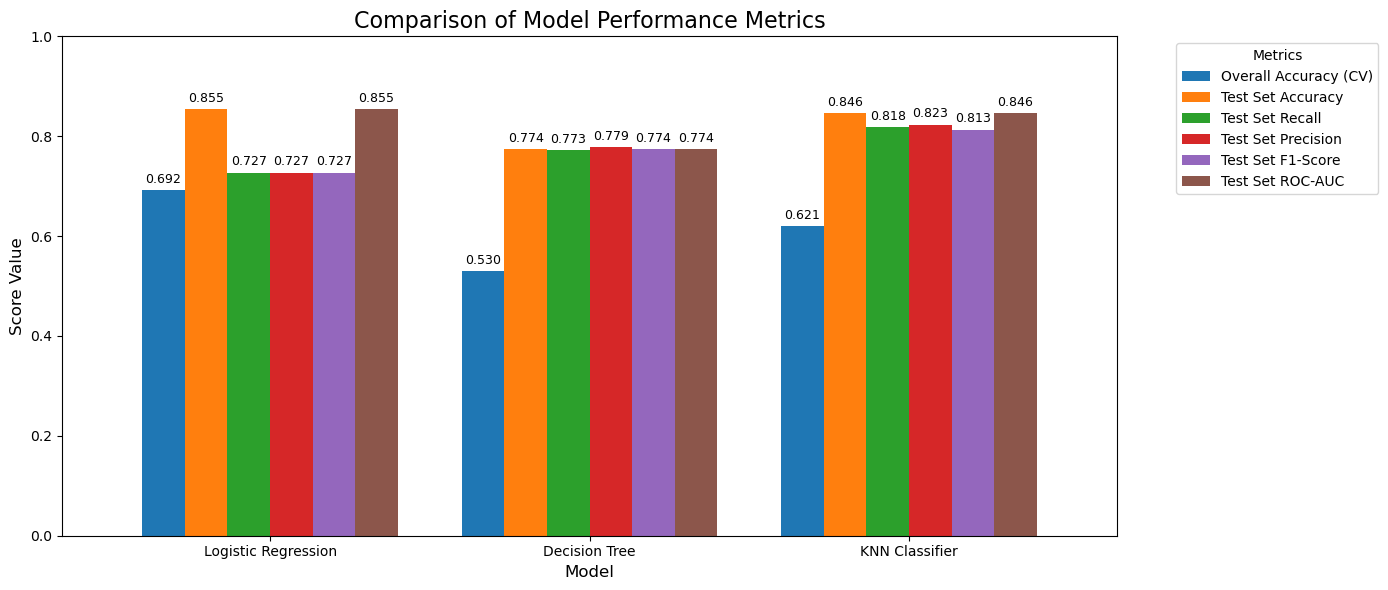

In [211]:
df_plot = model_performance.T

# Create the Bar Plot 
plt.figure(figsize=(14, 6))

# Plot the bars
ax = df_plot.plot(kind='bar', figsize=(14, 6), rot=0, width=0.8)

# Customize the Plot 
plt.title('Comparison of Model Performance Metrics', fontsize=16)
plt.ylabel('Score Value', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0.0, 1.0) # Set Y-axis limit for scores (0 to 1)

# Add value labels on top of the bars for clarity
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

# Place the legend outside the plot
plt.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

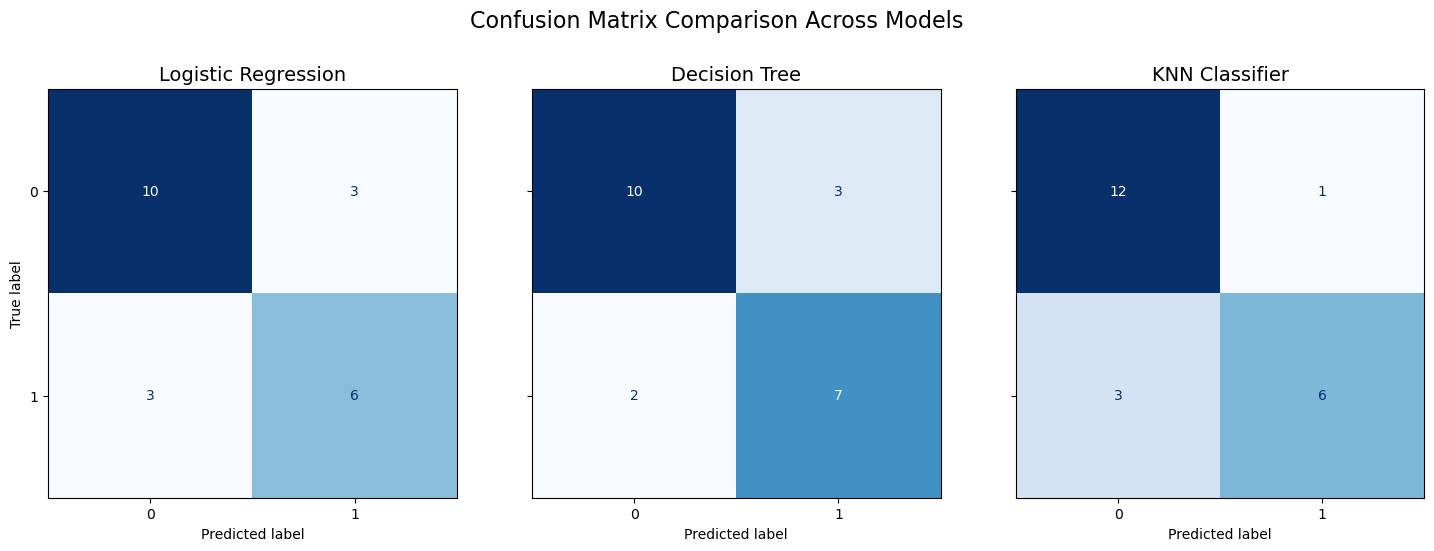

In [214]:
# Calculate the three confusion matrices
cm_lr = confusion_matrix(y_test, lr_y_pred)
cm_dt = confusion_matrix(y_test, dt_y_pred)
cm_knn = confusion_matrix(y_test, knn_y_pred)

# Define lists for iteration
matrices = [cm_lr, cm_dt, cm_knn]
model_titles = ['Logistic Regression', 'Decision Tree', 'KNN Classifier']
class_labels = [0, 1] 

# Create the figure and subplots (1 row, 3 columns)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
plt.suptitle('Confusion Matrix Comparison Across Models', fontsize=16, y=1.05)
axes = axes.flatten() # Flattens the 1x3 array of axes for easy indexing

# Loop through the matrices and plot them
for i, cm in enumerate(matrices):
    ax = axes[i]
    
    # Create the ConfusionMatrixDisplay object
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                  display_labels=class_labels)

    # Plot the matrix on the current subplot
    disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
    
    # Set the title
    ax.set_title(model_titles[i], fontsize=14)
    
    # Remove redundant y-axis labels from the middle and right plots for a cleaner look
    if i > 0:
        ax.set_ylabel('')
        ax.set_yticklabels([])

plt.tight_layout()
plt.show()